# Домашнее задание. Обучение нейронных сетей

Цель работы — закрепить две части лекции:

1. ручное вычисление градиентов через backpropagation;
2. экспериментальное сравнение способов обучения нейросети.

Работу нужно выполнить в одном `.ipynb` файле.  
В ноутбуке должны быть код, графики и короткие выводы.

---

## Задача 1. Backpropagation для двухслойной сети

Рассмотрим сеть для одного объекта:

$$
u^1=W^1x+b^1,
\qquad
a^1=\operatorname{ReLU}(u^1),
$$

$$
u^2=W^2a^1+b^2,
\qquad
\widehat y=u^2.
$$

Функция потерь:

$$
L=(\widehat y-y)^2.
$$

Здесь

$$
x\in\mathbb R^d,\qquad
W^1\in\mathbb R^{h\times d},
\qquad
b^1\in\mathbb R^h,
$$

$$
W^2\in\mathbb R^{1\times h},
\qquad
b^2\in\mathbb R.
$$

### Требуется

1. Вывести формулы для градиентов:

$$
\frac{\partial L}{\partial W^2},
\qquad
\frac{\partial L}{\partial b^2},
\qquad
\frac{\partial L}{\partial W^1},
\qquad
\frac{\partial L}{\partial b^1}.
$$

2. Реализовать вычисление этих градиентов вручную в PyTorch или NumPy.

3. Реализовать ту же сеть через PyTorch autograd и сравнить ручные градиенты с градиентами, полученными через

```python
loss.backward()
```
Проверить совпадение градиентов численно, например через

```python
torch.max(torch.abs(grad_manual - grad_autograd))
```

## Задача 2. Экспериментальное сравнение способов обучения MLP

Выберите один датасет для задачи регрессии или классификации.

Можно использовать, например:

- синтетическую регрессию;
- `load_digits`;
- `make_moons`;
- `make_classification`;
- любой другой небольшой датасет из `sklearn`.

Разбейте данные на train и validation.

Постройте MLP и сравните несколько вариантов обучения.

### Минимальные требования

Нужно сравнить хотя бы **три** варианта из списка:

1. разные функции активации: `ReLU`, `tanh`, `sigmoid`;
2. разные оптимизаторы: `SGD`, `SGD + momentum`, `Adam`;
3. разные инициализации: стандартная, Xavier, He;
4. `weight_decay`;
5. `dropout`;
6. `BatchNorm`;
7. `early stopping`;
8. разная глубина или ширина сети.

### Что нужно сделать

Для каждого варианта:

1. обучить модель;
2. построить графики

$$
L_{\mathrm{train}}(t),
\qquad
L_{\mathrm{val}}(t);
$$

3. посчитать итоговое качество на validation set;
4. оформить результаты в таблицу.

Пример таблицы:

| Модель | Особенности | Train loss | Validation loss | Validation metric |
|---|---|---:|---:|---:|
| Baseline | ReLU + Adam | ... | ... | ... |
| Model 2 | + weight decay | ... | ... | ... |
| Model 3 | + dropout | ... | ... | ... |

Для классификации можно использовать accuracy.  
Для регрессии можно использовать MSE.

---

## Выводы

В конце работы нужно кратко ответить на вопросы.

1. Какая модель дала лучшее качество на validation set?
2. Было ли переобучение? По каким графикам это видно?
3. Что сильнее всего повлияло на обучение?

---

## Что сдавать

Один `.ipynb` файл.

В нём должны быть:

- математический вывод backpropagation;
- проверка ручных градиентов через autograd;
- эксперимент с MLP;
- графики train/validation loss;
- таблица результатов;
- краткие выводы.

# Задача 1


Для того чтобы вывести градиенты функции потерь по всем параметрам сети, воспользуемся правилом дифференцирования сложной функции (chain rule).


Исходные уравнения:

* $u^1 = W^1 x + b^1$ — Линейное преобразование первого слоя: вычисление взвешенной суммы входных признаков $x$ и добавление вектора смещения (bias).

* $a^1 = \operatorname{ReLU}(u^1)$ — Активация первого слоя: применение нелинейной функции ReLU  к выходу линейной части для получения признаков скрытого слоя.

* $u^2 = W^2 a^1 + b^2$ — Линейное преобразование второго слоя: вычисление выхода сети на основе активированных признаков скрытого слоя.

* $\widehat{y} = u^2$ — Выход сети : в данной задаче регрессии активация на последнем слое отсутствует (линейная), поэтому предсказание равно результату линейного преобразования.

* $L = (\widehat{y} - y)^2$ — Функция потерь : квадратичная ошибка (MSE для одного объекта), измеряющая отклонение предсказания сети от истинного целевого значения $y$.

Схема прохождения сигнала

$x$ (Входной вектор)

     ↓

$\times W^1 + b^1$ (Линейное преобразование первого слоя)

     ↓

$u^1$ (Пред-активация скрытого слоя)

     ↓

$\operatorname{ReLU}(\cdot)$ (Функция активации)

     ↓

$a^1$ (Активированные признаки скрытого слоя)

     ↓

$\times W^2 + b^2$ (Линейное преобразование второго слоя)

     ↓

$u^2 = \widehat{y}$ (Выход сети / Предсказание)

     ↓

$(\widehat{y} - y)^2$ (Вычисление функции потерь $L$)

     ↓

$L$ (Итоговая ошибка)

1. Производная функции потерь

Сначала вычислим внешнюю производную — по предсказанию $\widehat{y}$:

$$\frac{\partial L}{\partial \widehat{y}} = \frac{\partial}{\partial \widehat{y}} (\widehat{y} - y)^2 = 2(\widehat{y} - y)$$

Поскольку $\widehat{y} = u^2$, то частная производная $\frac{\partial \widehat{y}}{\partial u^2} = 1$. Следовательно:

$$\frac{\partial L}{\partial u^2} = \frac{\partial L}{\partial \widehat{y}} \cdot \frac{\partial \widehat{y}}{\partial u^2} = 2(\widehat{y} - y)$$

2. Градиенты для второго слоя ($W^2, b^2$)

Здесь параметры входят в линейное уравнение $u^2 = W^2 a^1 + b^2$.

Для $b^2$:

Так как $b^2$ — это константа в сумме, её производная $\frac{\partial u^2}{\partial b^2} = 1$.

$$\frac{\partial L}{\partial b^2} = \frac{\partial L}{\partial u^2} \cdot \frac{\partial u^2}{\partial b^2} = 2(\widehat{y} - y) \cdot 1 = \mathbf{2(\widehat{y} - y)}$$

Для $W^2$:

Заметим, что $W^2$ — это строка размера $1 \times h$. По правилам матричного дифференцирования $\frac{\partial (Wa)}{\partial W} = a^T$.

$$\frac{\partial L}{\partial W^2} = \frac{\partial L}{\partial u^2} \cdot \frac{\partial u^2}{\partial W^2} = \underbrace{2(\widehat{y} - y)}_{1 \times 1} \cdot \underbrace{(a^1)^T}_{1 \times h} = \mathbf{2(\widehat{y} - y) (a^1)^T}$$

3. Обратный проход через нелинейность (ReLU)

Чтобы дойти до первого слоя, нужно найти, как функция потерь меняется в зависимости от $u^1$. Сначала найдем производную по $a^1$:

$$\frac{\partial L}{\partial a^1} = \left( \frac{\partial u^2}{\partial a^1} \right)^T \cdot \frac{\partial L}{\partial u^2} = (W^2)^T \cdot 2(\widehat{y} - y)$$

(Размерность: $(h \times 1) \cdot (1 \times 1) = h \times 1$)

Теперь учтем активацию $a^1 = \operatorname{ReLU}(u^1)$. Производная ReLU:

$$\operatorname{ReLU}'(u) = \begin{cases} 1, & u > 0 \\ 0, & u \le 0 \end{cases}$$

Применим это поэлементно (обозначим как $\operatorname{step}(u^1)$):

$$\frac{\partial L}{\partial u^1} = \frac{\partial L}{\partial a^1} \odot \operatorname{ReLU}'(u^1) = \mathbf{(W^2)^T \cdot 2(\widehat{y} - y) \odot \operatorname{step}(u^1)}$$

4. Градиенты для первого слоя ($W^1, b^1$)

Параметры входят в уравнение $u^1 = W^1 x + b^1$. Мы уже знаем «входящую» ошибку $\frac{\partial L}{\partial u^1}$ (обозначим её для краткости как $\delta^1$).

Для $b^1$:

$$\frac{\partial L}{\partial b^1} = \frac{\partial L}{\partial u^1} \cdot \frac{\partial u^1}{\partial b^1} = \delta^1 \cdot 1 = \mathbf{(W^2)^T \cdot 2(\widehat{y} - y) \odot \operatorname{step}(u^1)}$$

Для $W^1$:

Используем правило дифференцирования по матрице: $\frac{\partial (Wx)}{\partial W} = \delta \cdot x^T$.

$$\frac{\partial L}{\partial W^1} = \frac{\partial L}{\partial u^1} \cdot \frac{\partial u^1}{\partial W^1} = \delta^1 \cdot x^T = \mathbf{\left[ (W^2)^T \cdot 2(\widehat{y} - y) \odot \operatorname{step}(u^1) \right] x^T}$$

(Размерность: $(h \times 1) \cdot (1 \times d) = h \times d$, что совпадает с размерностью $W^1$)

Итоговая сводка формул:

$\delta^2 = 2(\widehat{y} - y)$

$\frac{\partial L}{\partial b^2} = \delta^2$

$\frac{\partial L}{\partial W^2} = \delta^2 (a^1)^T$

$\delta^1 = ((W^2)^T \delta^2) \odot \operatorname{step}(u^1)$

$\frac{\partial L}{\partial b^1} = \delta^1$

$\frac{\partial L}{\partial W^1} = \delta^1 x^T$

In [15]:
import torch

In [16]:
torch.manual_seed(42)

h, d  = 5,  4
# создаем входные и выходные данные
x = torch.randn(d, 1)
y = torch.tensor([[1.0]])

# Параметры сети с включенным autograd

W1 = torch.randn(h, d, requires_grad=True)
b1 = torch.randn(h, 1, requires_grad=True)
W2 = torch.randn(1, h, requires_grad=True)
b2 = torch.randn(1, 1, requires_grad=True)
print(f'x: {x.size()}')
print(f'W1: {W1.size()}')
print(f'b1: {b1.size()}')
print(f'W2: {W2.size()}')
print(f'b2: {b2.size()}')

x: torch.Size([4, 1])
W1: torch.Size([5, 4])
b1: torch.Size([5, 1])
W2: torch.Size([1, 5])
b2: torch.Size([1, 1])


In [17]:
# Forward pass
u1 = W1 @ x + b1
print(f'u1: {u1.size()} {u1}' )
a1 = torch.relu(u1)
print(f'a1: {a1.size()} {a1}' )
u2 = W2 @ a1 + b2
print(f'u2: {u2.size()} {u2}' )
loss = (u2 - y)**2
print(f'loss: {loss.size()} {loss}' )
loss.backward()

u1: torch.Size([5, 1]) tensor([[-0.0595],
        [-0.1604],
        [ 0.0463],
        [-0.2693],
        [-0.2182]], grad_fn=<AddBackward0>)
a1: torch.Size([5, 1]) tensor([[0.0000],
        [0.0000],
        [0.0463],
        [0.0000],
        [0.0000]], grad_fn=<ReluBackward0>)
u2: torch.Size([1, 1]) tensor([[0.1575]], grad_fn=<AddBackward0>)
loss: torch.Size([1, 1]) tensor([[0.7098]], grad_fn=<PowBackward0>)


In [18]:
with torch.no_grad():
  # 1. Ошибка на самом выходе (delta2)
    # dL/dy_hat = 2 * (y_hat - y)
    delta2 = 2 * (u2 - y)

    # 2. Градиенты второго слоя
    # dL/db2 = delta2
    grad_b2_manual = delta2.clone()
    # dL/dW2 = delta2 * (a1)^T
    grad_W2_manual = delta2 @ a1.t()

    # 3. Проход назад через ReLU и W2 к первому слою (delta1)
    # Сначала считаем dL/da1 = (W2)^T * delta2
    # Затем применяем производную ReLU (умножаем на маску)
    relu_mask = (u1 > 0).float()
    delta1 = (W2.t() @ delta2) * relu_mask

    # 4. Градиенты первого слоя
    # dL/db1 = delta1
    grad_b1_manual = delta1.clone()
    # dL/dW1 = delta1 * x^T
    grad_W1_manual = delta1 @ x.t()

In [19]:
def check(name, manual, auto):
    error = torch.max(torch.abs(manual - auto)).item()
    status = "OK" if error < 1e-7 else "ОШИБКА"
    print(f"{name}: Max Diff = {error:.2e} | {status}")

In [20]:
check("W2", grad_W2_manual, W2.grad)
check("b2", grad_b2_manual, b2.grad)
check("W1", grad_W1_manual, W1.grad)
check("b1", grad_b1_manual, b1.grad)

W2: Max Diff = 0.00e+00 | OK
b2: Max Diff = 0.00e+00 | OK
W1: Max Diff = 0.00e+00 | OK
b1: Max Diff = 0.00e+00 | OK


# Задание 2

In [21]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Загрузка датасета рукописных цифр
digits = load_digits()
X, y = digits.data, digits.target

# Разделение на обучающую и валидационную выборки
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Стандартизация признаков для стабильного обучения
scaler = StandardScaler()
X_train = torch.FloatTensor(scaler.fit_transform(X_train))
X_val = torch.FloatTensor(scaler.transform(X_val))
y_train = torch.LongTensor(y_train)
y_val = torch.LongTensor(y_val)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер валидационной выборки: {X_val.shape}")

Размер обучающей выборки: torch.Size([1437, 64])
Размер валидационной выборки: torch.Size([360, 64])


In [22]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, activation):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            activation(),
            nn.Linear(hidden_dim, hidden_dim),
            activation(),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        return self.net(x)

def train_model(model, optimizer, epochs=200, use_early_stopping=False):
    criterion = nn.CrossEntropyLoss()
    train_losses, val_losses = [], []

    patience = 15
    best_val_loss = float('inf')
    counter = 0

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val)
            val_loss = criterion(val_outputs, y_val)
            val_losses.append(val_loss.item())

            # Логика ранней остановки
            if use_early_stopping:
                if val_loss < best_val_loss:
                    best_val_loss = val_loss
                    counter = 0
                else:
                    counter += 1
                    if counter >= patience:
                        print(f"Early stopping на эпохе {epoch}")
                        break

    return train_losses, val_losses

Early stopping на эпохе 139


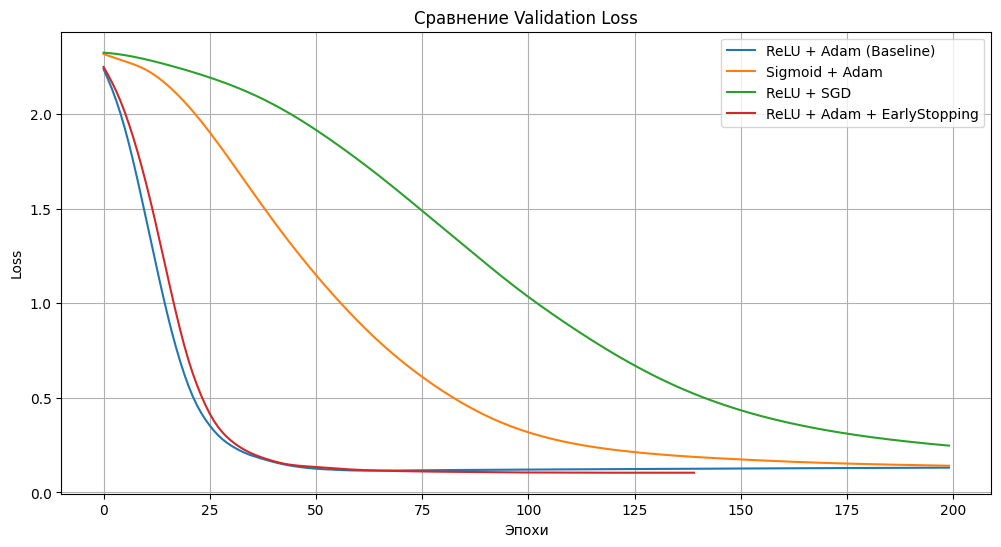

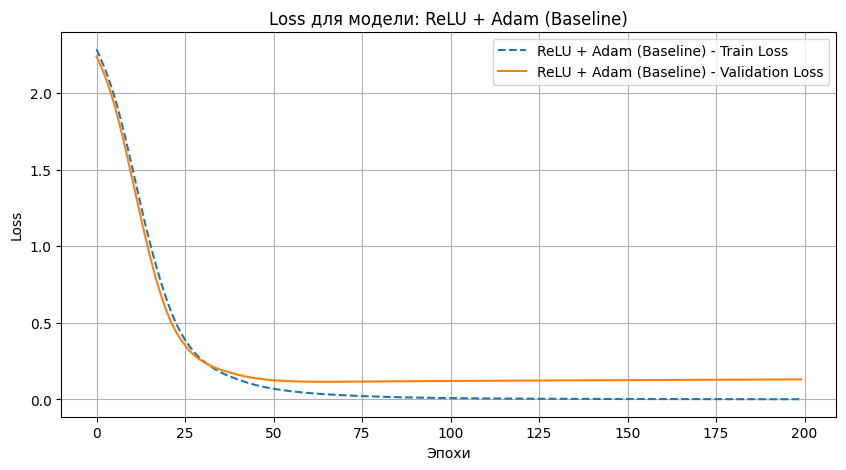

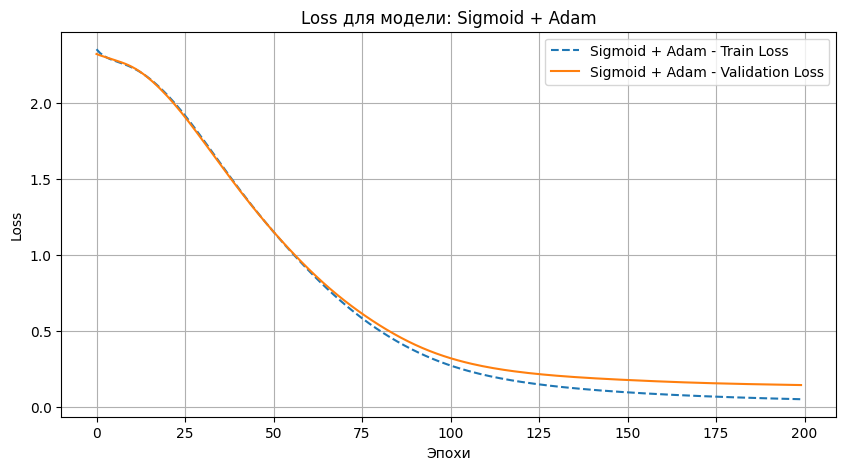

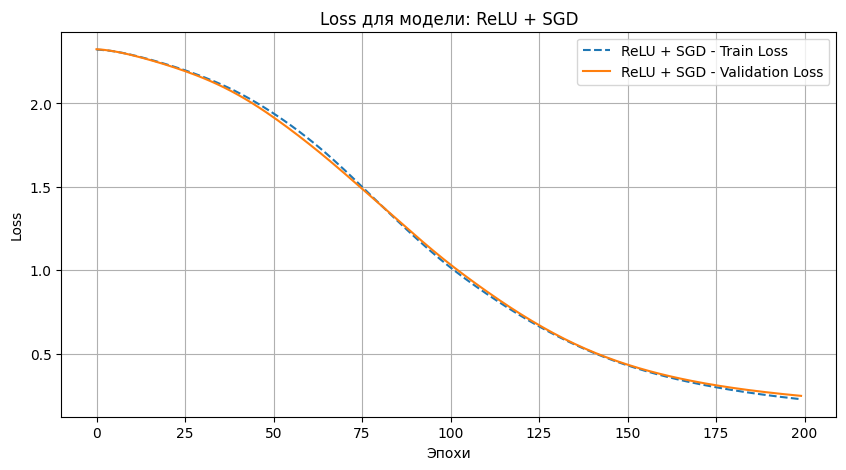

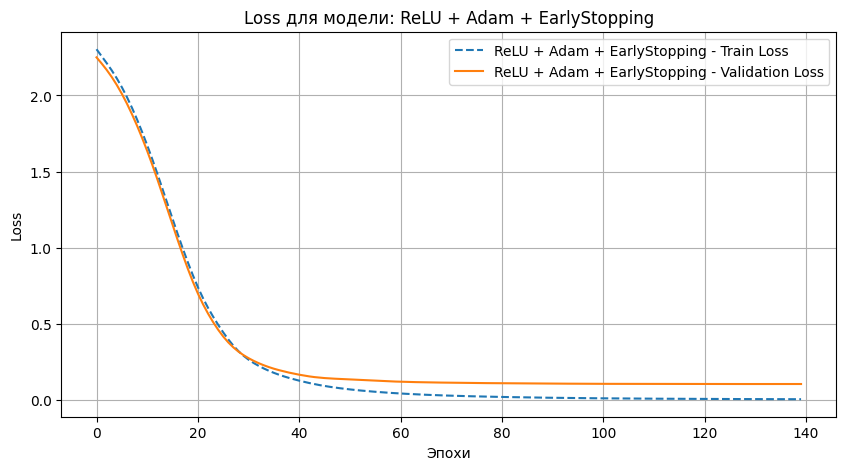

In [ ]:
results = []
configs = [
    {"name": "ReLU + Adam (Baseline)", "act": nn.ReLU, "opt": "Adam", "es": False},
    {"name": "Sigmoid + Adam", "act": nn.Sigmoid, "opt": "Adam", "es": False},
    {"name": "ReLU + SGD", "act": nn.ReLU, "opt": "SGD", "es": False},
    {"name": "ReLU + Adam + EarlyStopping", "act": nn.ReLU, "opt": "Adam", "es": True},
]

all_train_losses = {}
all_val_losses = {}

for config in configs:
    model = MLP(input_dim=64, hidden_dim=32, output_dim=10, activation=config["act"])

    if config["opt"] == "Adam":
        optimizer = optim.Adam(model.parameters(), lr=0.005)
    else:
        optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

    # Обучение
    t_loss_history, v_loss_history = train_model(model, optimizer, use_early_stopping=config["es"])

    all_train_losses[config["name"]] = t_loss_history
    all_val_losses[config["name"]] = v_loss_history

    model.eval()
    with torch.no_grad():
        preds = torch.argmax(model(X_val), dim=1)
        accuracy = (preds == y_val).float().mean().item()

    results.append({
        "Модель": config["name"],
        "Train Loss": t_loss_history[-1],
        "Val Loss": v_loss_history[-1],
        "Val Accuracy": accuracy
    })

fig_summary, ax_summary = plt.subplots(figsize=(12, 6))
for config_name, v_loss_history in all_val_losses.items():
    ax_summary.plot(v_loss_history, label=config_name)

ax_summary.set_title("Сравнение Validation Loss")
ax_summary.set_xlabel("Эпохи")
ax_summary.set_ylabel("Loss")
ax_summary.legend()
ax_summary.grid(True)
plt.show() # Display the summary figure

for config in configs:
    config_name = config["name"]
    t_loss_history = all_train_losses[config_name]
    v_loss_history = all_val_losses[config_name]

    plt.figure(figsize=(10, 5))
    plt.plot(t_loss_history, label=f'{config_name} - Train Loss', linestyle='--')
    plt.plot(v_loss_history, label=f'{config_name} - Validation Loss')
    plt.title(f'Loss для модели: {config_name}')
    plt.xlabel('Эпохи')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()


In [24]:
df_results = pd.DataFrame(results)
# Форматирование для красоты
df_results["Train Loss"] = df_results["Train Loss"].map("{:.4f}".format)
df_results["Val Loss"] = df_results["Val Loss"].map("{:.4f}".format)
df_results["Val Accuracy"] = df_results["Val Accuracy"].map("{:.2%}".format)

print(df_results.to_markdown(index=False))

| Модель                      |   Train Loss |   Val Loss | Val Accuracy   |
|:----------------------------|-------------:|-----------:|:---------------|
| ReLU + Adam (Baseline)      |       0.0016 |     0.131  | 96.67%         |
| Sigmoid + Adam              |       0.0479 |     0.1411 | 95.28%         |
| ReLU + SGD                  |       0.2273 |     0.2475 | 94.44%         |
| ReLU + Adam + EarlyStopping |       0.0043 |     0.1043 | 97.50%         |


В конце работы нужно кратко ответить на вопросы.

1. Какая модель дала лучшее качество на validation set?
2. Было ли переобучение? По каким графикам это видно?
3. Что сильнее всего повлияло на обучение?

* Лучше всего себя показала сеть с ReLu + Adam + EarlyStopping. Это видно по validation loss и accuracy.

* Переобучения сильного не было, что можно видеть из графиков train и validation loss кривых. Есть небольшой gap, но он в пределах разумного.

* На качество обучения сильнее всего повлияла связка ReLu + Adam + EarlyStopping. Adam ускорил сходимость за счёт адаптивного learning rate. ReLu - добавляет нелинейное преобразование для сигналов для лучшей разделимости. EarlyStopping - не дает переобучиться под трейн на большом количестве эпох.